<a href="https://colab.research.google.com/github/dishanth2k6/Company-Projects/blob/main/Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import io


uploaded = files.upload()


file_name = list(uploaded.keys())[0]
print(f"\nSuccessfully uploaded: {file_name}")

Saving twitter_training.csv to twitter_training.csv

Successfully uploaded: twitter_training.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

print("NLP and Classification libraries loaded successfully!")

NLP and Classification libraries loaded successfully!


In [3]:
# Load dataset with manual column names since it has no headers
df = pd.read_csv(io.BytesIO(uploaded[file_name]), header=None, names=['tweet_id', 'entity', 'sentiment', 'text'])

# 1. Drop rows where the text or sentiment column is missing
df = df.dropna(subset=['text', 'sentiment'])

# 2. Filter dataset to keep only Positive, Negative, and Neutral (removing 'Irrelevant')
df = df[df['sentiment'].isin(['Positive', 'Negative', 'Neutral'])]

# 3. Clean the text (remove URLs, handles, numbers, and special characters)
def clean_tweet(text):
    # Remove URLs/links
    text = re.sub(r"http\S+|www\S+|https\S+", "", str(text), flags=re.MULTILINE)
    # Remove user tags (@handle)
    text = re.sub(r'@\w+', '', text)
    # Keep only letters and single spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase and trim whitespaces
    return text.lower().strip()

print("Cleaning tweets... (This may take around 10-15 seconds)")
df['cleaned_text'] = df['text'].apply(clean_tweet)

print("Data Cleaning Complete! Remaining samples:", len(df))
df[['sentiment', 'cleaned_text']].head()

Cleaning tweets... (This may take around 10-15 seconds)
Data Cleaning Complete! Remaining samples: 61121


,sentiment,cleaned_text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,i am coming to the borders and i will kill you...
2,Positive,im getting on borderlands and i will kill you all
3,Positive,im coming on borderlands and i will murder you...
4,Positive,im getting on borderlands and i will murder y...


/tmp/ipykernel_2579/1423126625.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2', order=['Positive', 'Negative', 'Neutral'])


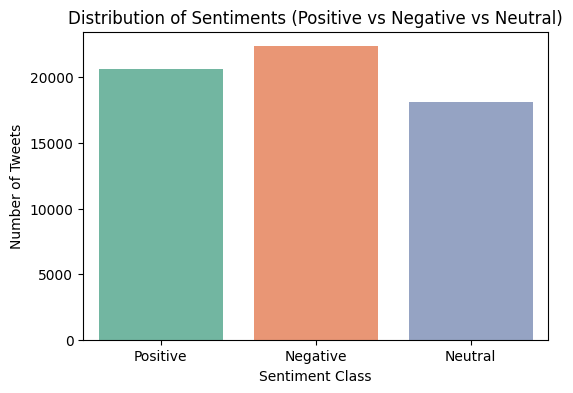

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2', order=['Positive', 'Negative', 'Neutral'])
plt.title('Distribution of Sentiments (Positive vs Negative vs Neutral)')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Tweets')
plt.show()

In [5]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment'])

# Initialize TF-IDF vectorizer (Top 5,000 words to ensure faster execution in Colab)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit and transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Text vectorized successfully! Training matrix shape: {X_train_tfidf.shape}")

Text vectorized successfully! Training matrix shape: (48896, 5000)


In [6]:
# Initialize models
lr_model = LogisticRegression(max_iter=1000)
nb_model = MultinomialNB()

# Train models
print("Training Logistic Regression Model...")
lr_model.fit(X_train_tfidf, y_train)

print("Training Naive Bayes Model...")
nb_model.fit(X_train_tfidf, y_train)

print("Both models trained successfully!")

Training Logistic Regression Model...
Training Naive Bayes Model...
Both models trained successfully!


In [7]:
# Make predictions
lr_preds = lr_model.predict(X_test_tfidf)
nb_preds = nb_model.predict(X_test_tfidf)

print("=== LOGISTIC REGRESSION ACCURACY & REPORT ===")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))

print("\n=== NAIVE BAYES ACCURACY & REPORT ===")
print(f"Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print(classification_report(y_test, nb_preds))

=== LOGISTIC REGRESSION ACCURACY & REPORT ===
Accuracy: 0.7519
              precision    recall  f1-score   support

    Negative       0.75      0.82      0.78      4472
     Neutral       0.74      0.66      0.70      3622
    Positive       0.77      0.76      0.76      4131

    accuracy                           0.75     12225
   macro avg       0.75      0.75      0.75     12225
weighted avg       0.75      0.75      0.75     12225


=== NAIVE BAYES ACCURACY & REPORT ===
Accuracy: 0.7143
              precision    recall  f1-score   support

    Negative       0.69      0.82      0.75      4472
     Neutral       0.75      0.55      0.64      3622
    Positive       0.71      0.74      0.73      4131

    accuracy                           0.71     12225
   macro avg       0.72      0.70      0.71     12225
weighted avg       0.72      0.71      0.71     12225

